In [145]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(GenomicRanges)
  library(IRanges)
  library(S4Vectors)
  library(ComplexHeatmap)
  library(circlize)
  library(ggforce)
  library(ggpubr)
  library(viridis)
  library(gtools)
  library(tibble)
  library(scales)
ibrary(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(gtools)

  library(ggrepel)
  library(broom)
})

In [146]:
# Paths
# ==================================================
setwd("/home/mjehangir/telomere-sv-analysis/data/")
fig6_dir <- "/home/mjehangir/telomere-sv-analysis/plots/fig6/"
repeat_file <- "/home/mjehangir/softwares/SVAN/chm13/REPEATS_chm13.bed"

In [147]:
# Helpers
# ==================================================
save_pdf <- function(plot, filename, width, height, dpi = 300) {
  ggsave(filename = filename, plot = plot, width = width, height = height,
         units = "in", dpi = dpi, device = "pdf")
}

theme_pub <- function(base_size = 12) {
  theme_classic(base_size = base_size) +
    theme(
      axis.line = element_line(linewidth = 0.5, colour = "black"),
      axis.ticks = element_line(linewidth = 0.5, colour = "black"),
      axis.text = element_text(colour = "black"),
      axis.title = element_text(face = "bold", colour = "black"),
      plot.title = element_text(face = "bold", hjust = 0.5),
      panel.background = element_blank(),
      plot.background = element_blank()
    )
}

In [148]:
# Load data
# ==================================================
cnv <- read.table("Mean_normalized_v3_tab.seg", header = TRUE, sep = "\t") %>%
  mutate(
    Length = loc.end - loc.start,
    CNV_status = case_when(
      seg.mean >= 0.2 ~ "Gain",
      seg.mean <= -0.2 ~ "Loss",
      TRUE ~ "Neutral"
    )
  )

chr_arm_size <- read.csv("chm13_p_q_arm_length.tsv", header = TRUE, sep = "\t")
telomeres_MAD <- read.table("telomeres_MAD.txt", sep = "\t", header = TRUE, check.names = FALSE)

In [149]:
# Global CNV summary
# ==================================================
baseline <- median(cnv$seg.mean, na.rm = TRUE)
mad_val <- mad(cnv$seg.mean, na.rm = TRUE)
loss_thr <- baseline - 2 * mad_val
gain_thr <- baseline + 2 * mad_val

cat("Loss threshold:", loss_thr, "\n")
cat("Gain threshold:", gain_thr, "\n")

Loss threshold: -0.3822143 
Gain threshold: 0.3822143 


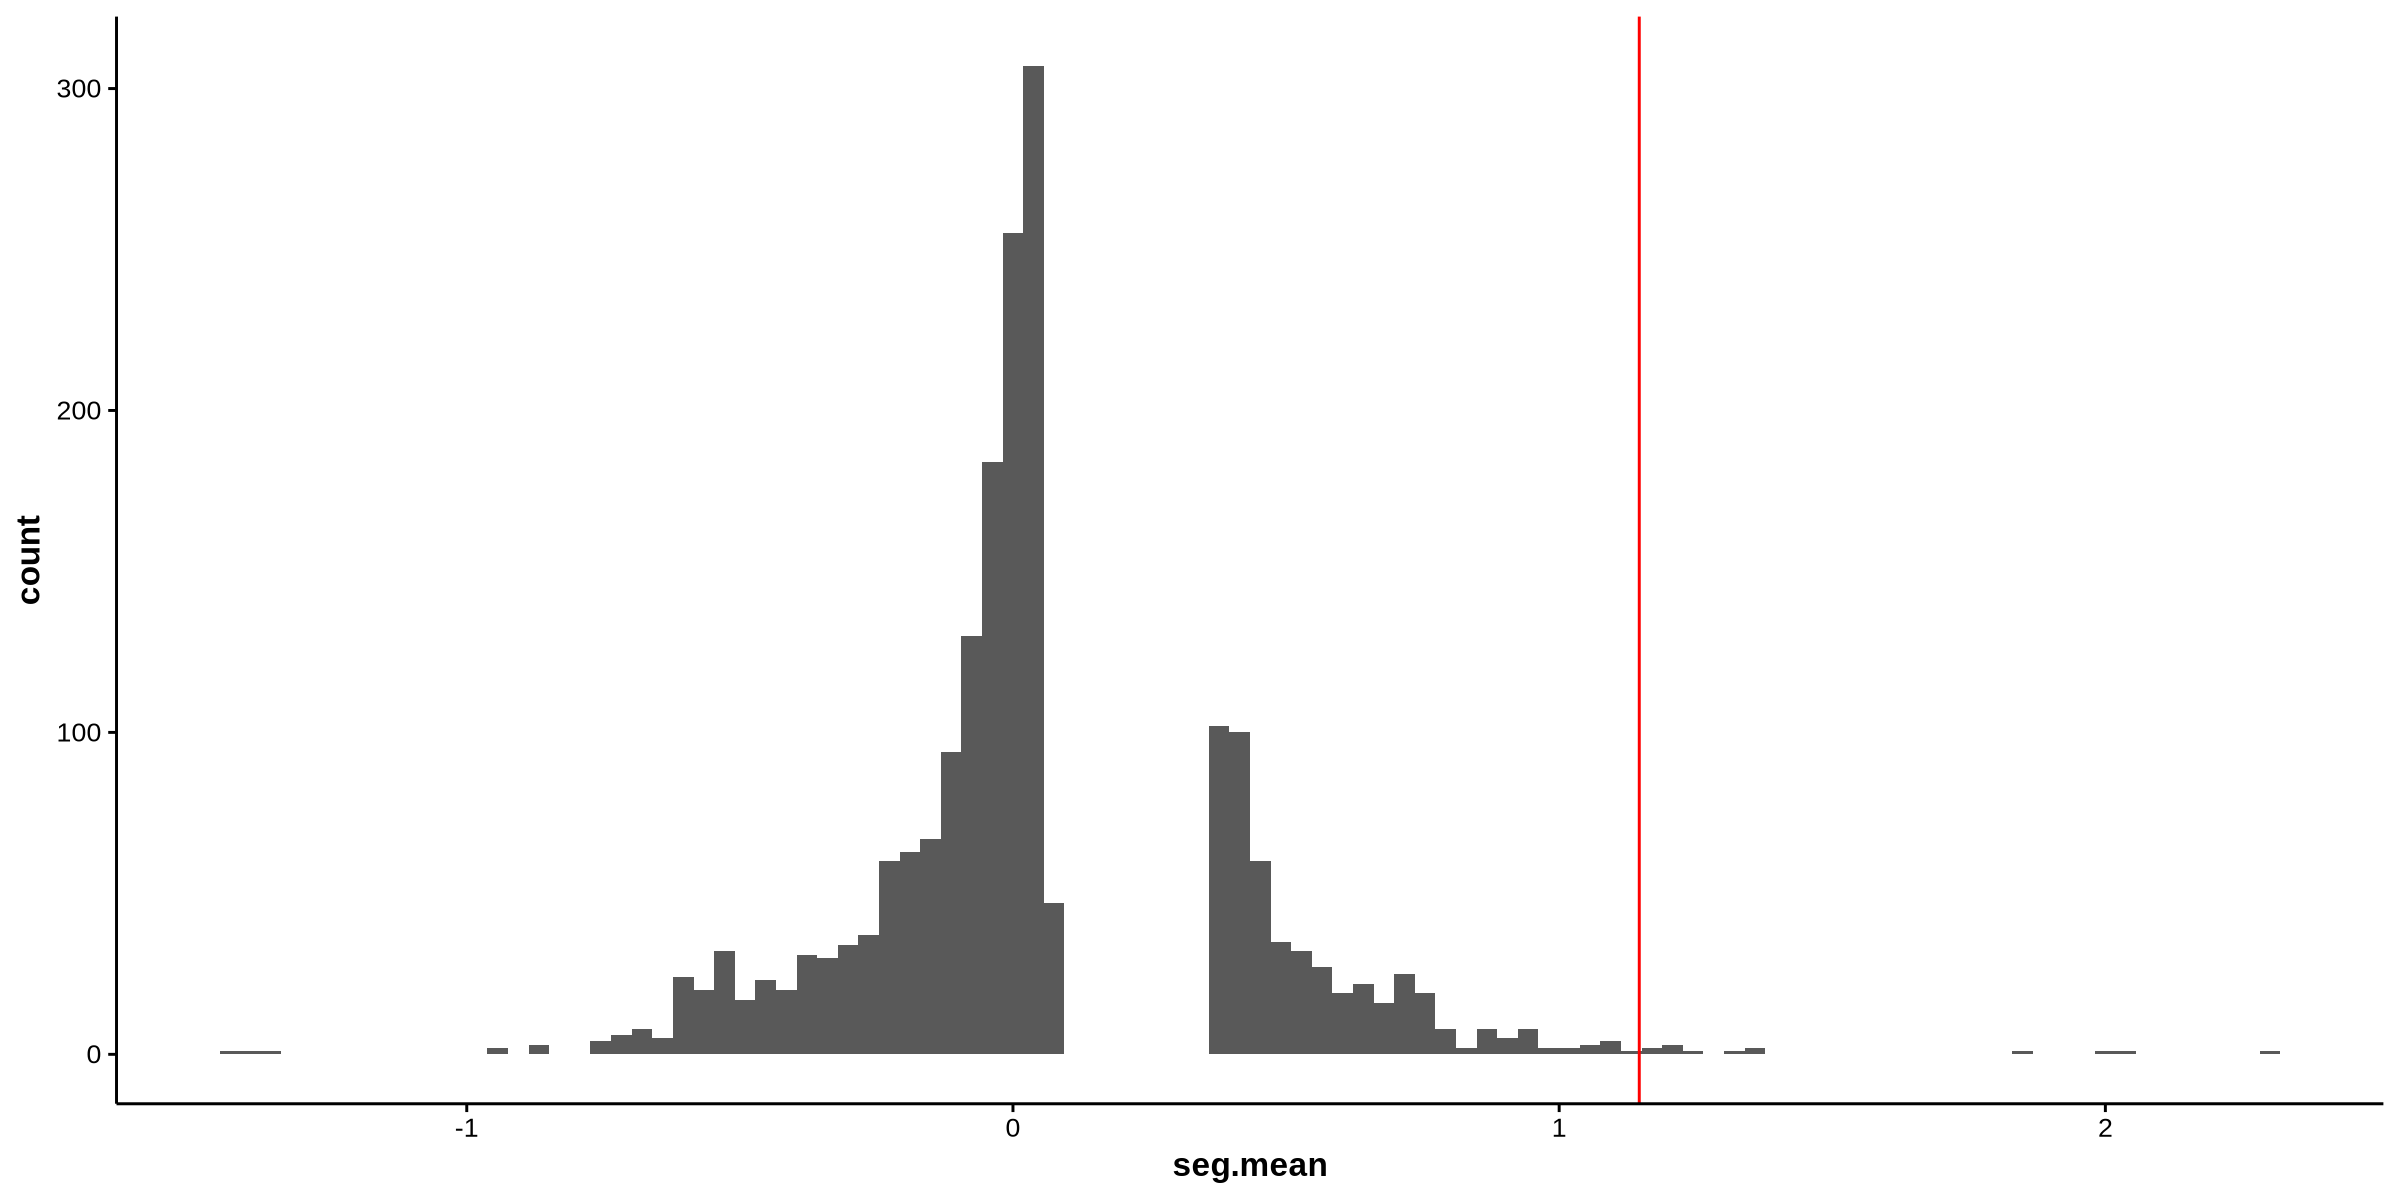

In [150]:
# High-gain region calling
# ==================================================
cnv_ecdna <- cnv %>%
  group_by(ID) %>%
  mutate(
    med_seg = median(seg.mean, na.rm = TRUE),
    mad_seg = mad(seg.mean, na.rm = TRUE),
    ecDNA_flag = ifelse(seg.mean > med_seg + 4 * mad_seg & Length >= 1000 & Length <= 5e6, 1, 0),
    Absolute_CN = round(2 * (2 ^ seg.mean), 1)
  ) %>%
  ungroup()

p_threshold <- ggplot(cnv, aes(x = seg.mean)) +
  geom_histogram(bins = 100) +
  geom_vline(aes(xintercept = median(seg.mean) + 6 * mad(seg.mean)), color = "red") +
  theme_pub(12)
print(p_threshold)

hg_table <- cnv_ecdna %>%
  filter(ecDNA_flag == 1) %>%
  select(ID, Chromosome = chrom, Start = loc.start, End = loc.end, Length, seg.mean, Absolute_CN) %>%
  arrange(desc(Absolute_CN))

#write.csv(hg_table, "Absolute_CN_HGs.csv", row.names = FALSE)

`summarise()` has grouped output by 'ID'. You can override using the `.groups`
argument.


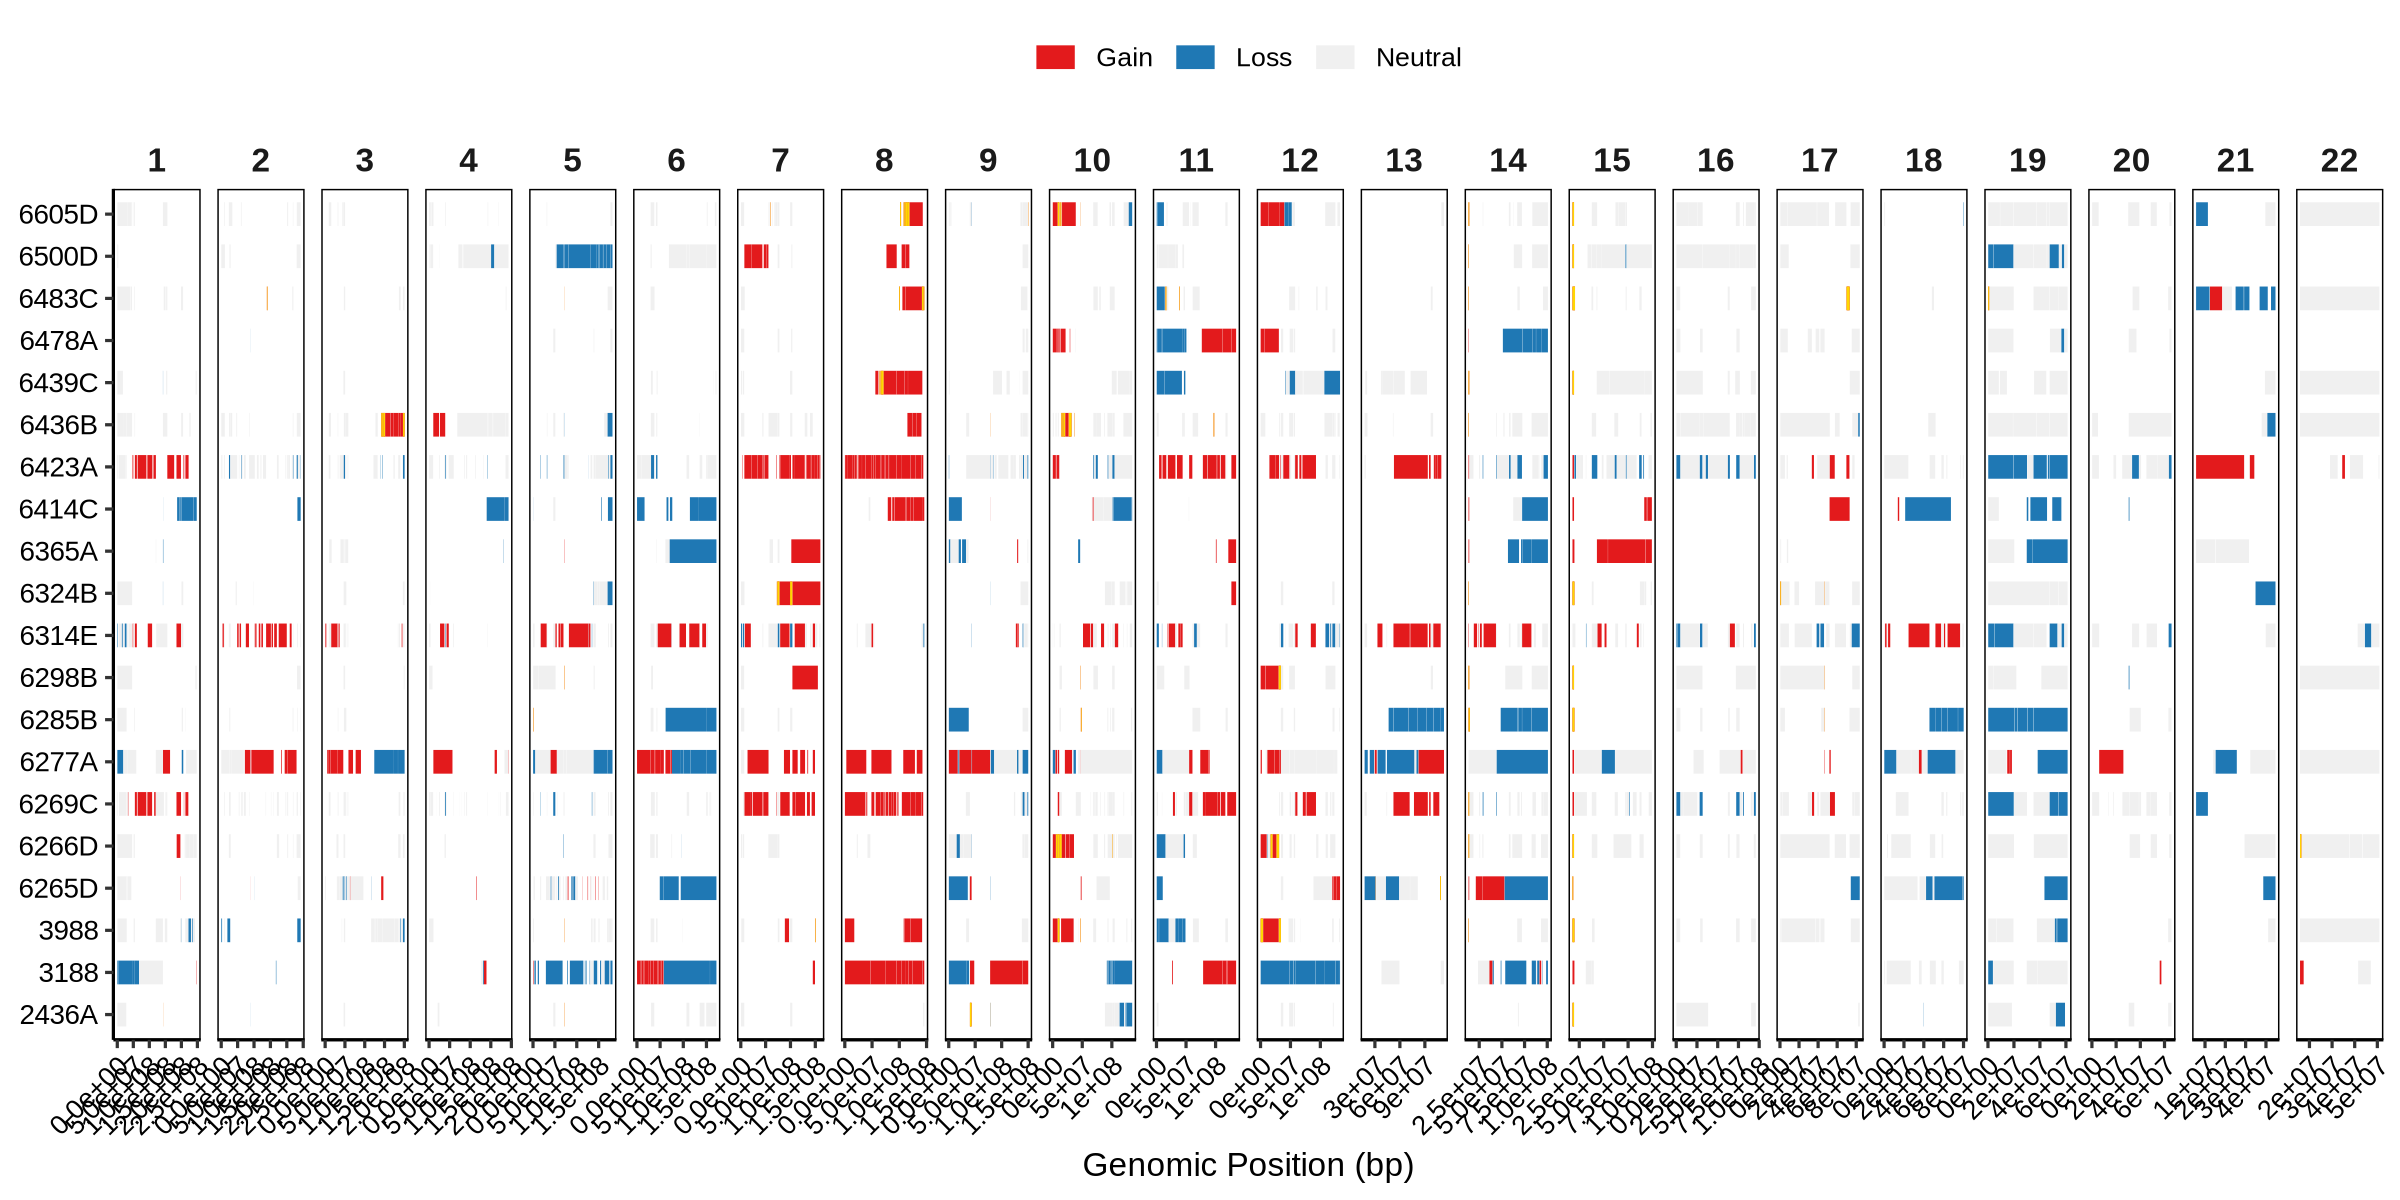

In [151]:
## 2. Summarize ecDNA per sample and chromosome
ecdna_summary <- cnv_ecdna %>%
  filter(ecDNA_flag == 1) %>%
  group_by(ID, chrom) %>%
  summarize(
    total_ecDNA_length = sum(Length),
    n_ecDNA_segments = n(),
    max_ecDNA_length = max(Length, na.rm = TRUE)
  ) %>%
  ungroup()

# 3. Optional: plot CNV heatmap with ecDNA highlighted
colors <- c("Loss" = "#1f78b4", "Neutral" = "#f0f0f0", "Gain" = "#e31a1c")

options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

p <- ggplot(cnv_ecdna, aes(x = loc.start, xend = loc.end, y = ID, yend = ID)) +
  geom_segment(aes(color = CNV_status), size = 4) +
  geom_segment(data = filter(cnv_ecdna, ecDNA_flag == 1),
               aes(x = loc.start, xend = loc.end, y = ID, yend = ID),
               color = "gold", size = 4) +  # ecDNA highlighted
  scale_color_manual(values = colors) +
  facet_wrap(~ chrom, scales = "free_x", nrow = 1) +
  theme_classic(base_size = 12) +
  labs(x = "Genomic Position (bp)", y = NULL, color = NULL) +
  theme(
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    legend.position = "top",
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )
p

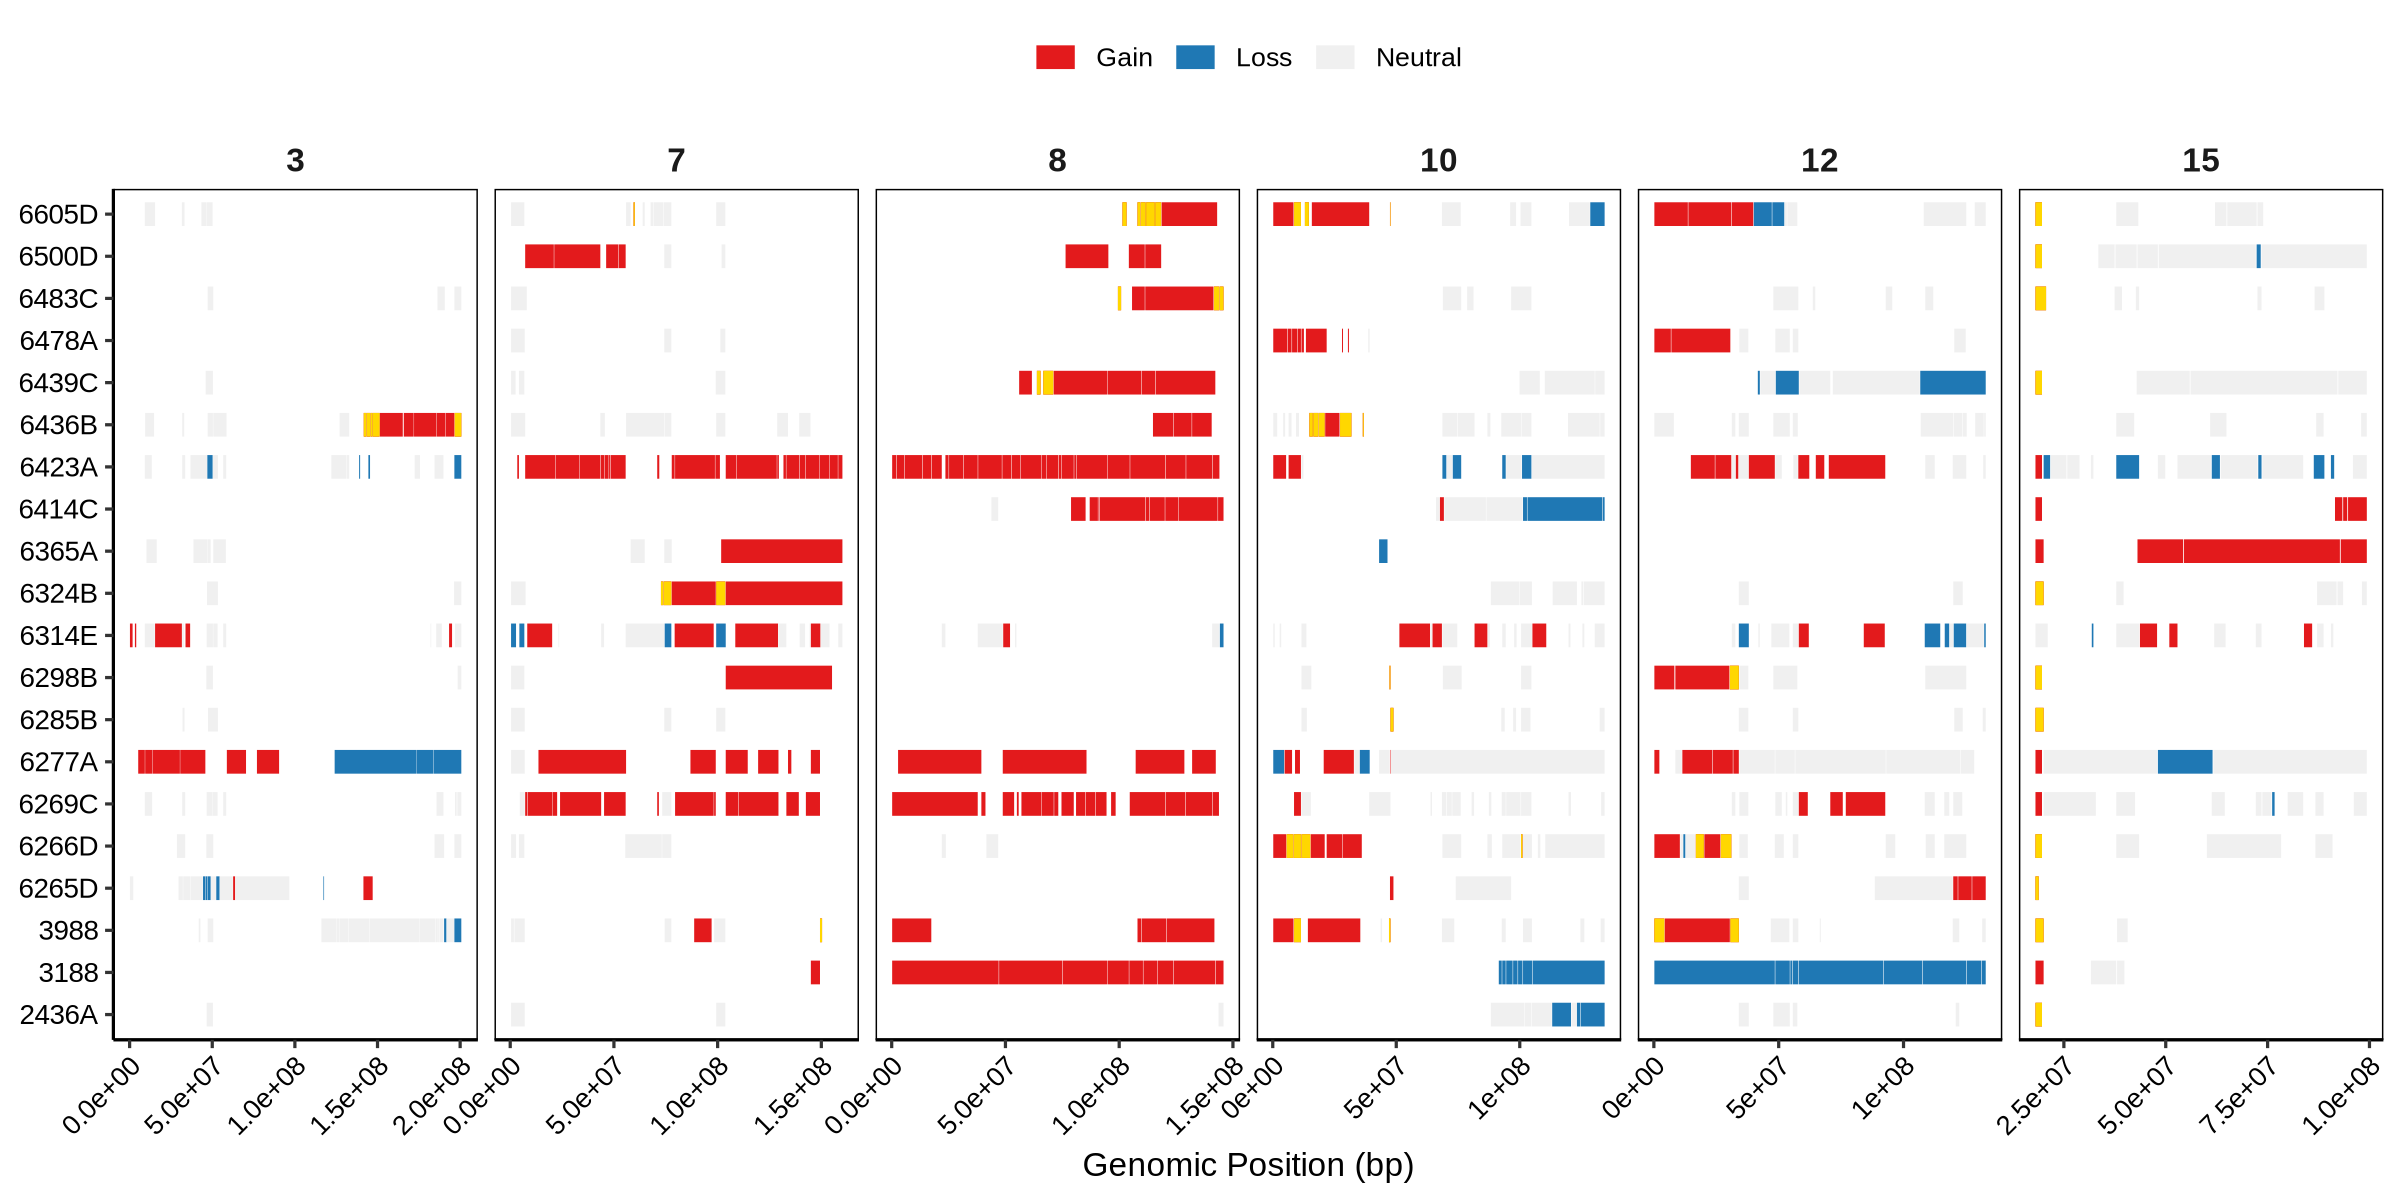

In [152]:
# Selected chromosomes in desired order
selected_chroms <- c("3", "7", "8", "10", "12", "15")

# Filter and set factor order
cnv_filtered <- cnv_ecdna %>%
  filter(chrom %in% selected_chroms) %>%
  mutate(chrom = factor(chrom, levels = selected_chroms))

# Plot
p <- ggplot(cnv_filtered, aes(x = loc.start, xend = loc.end, y = ID, yend = ID)) +
  geom_segment(aes(color = CNV_status), size = 4) +
  geom_segment(data = filter(cnv_filtered, ecDNA_flag == 1),
               aes(x = loc.start, xend = loc.end, y = ID, yend = ID),
               color = "gold", size = 4) +  # ecDNA highlighted
  scale_color_manual(values = colors) +
  facet_wrap(~ chrom, scales = "free_x", nrow = 1) +
  theme_classic(base_size = 12) +
  labs(x = "Genomic Position (bp)", y = NULL, color = NULL) +
  theme(
    axis.text.y = element_text(size = 10, color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold"),
    legend.position = "top",
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )

p


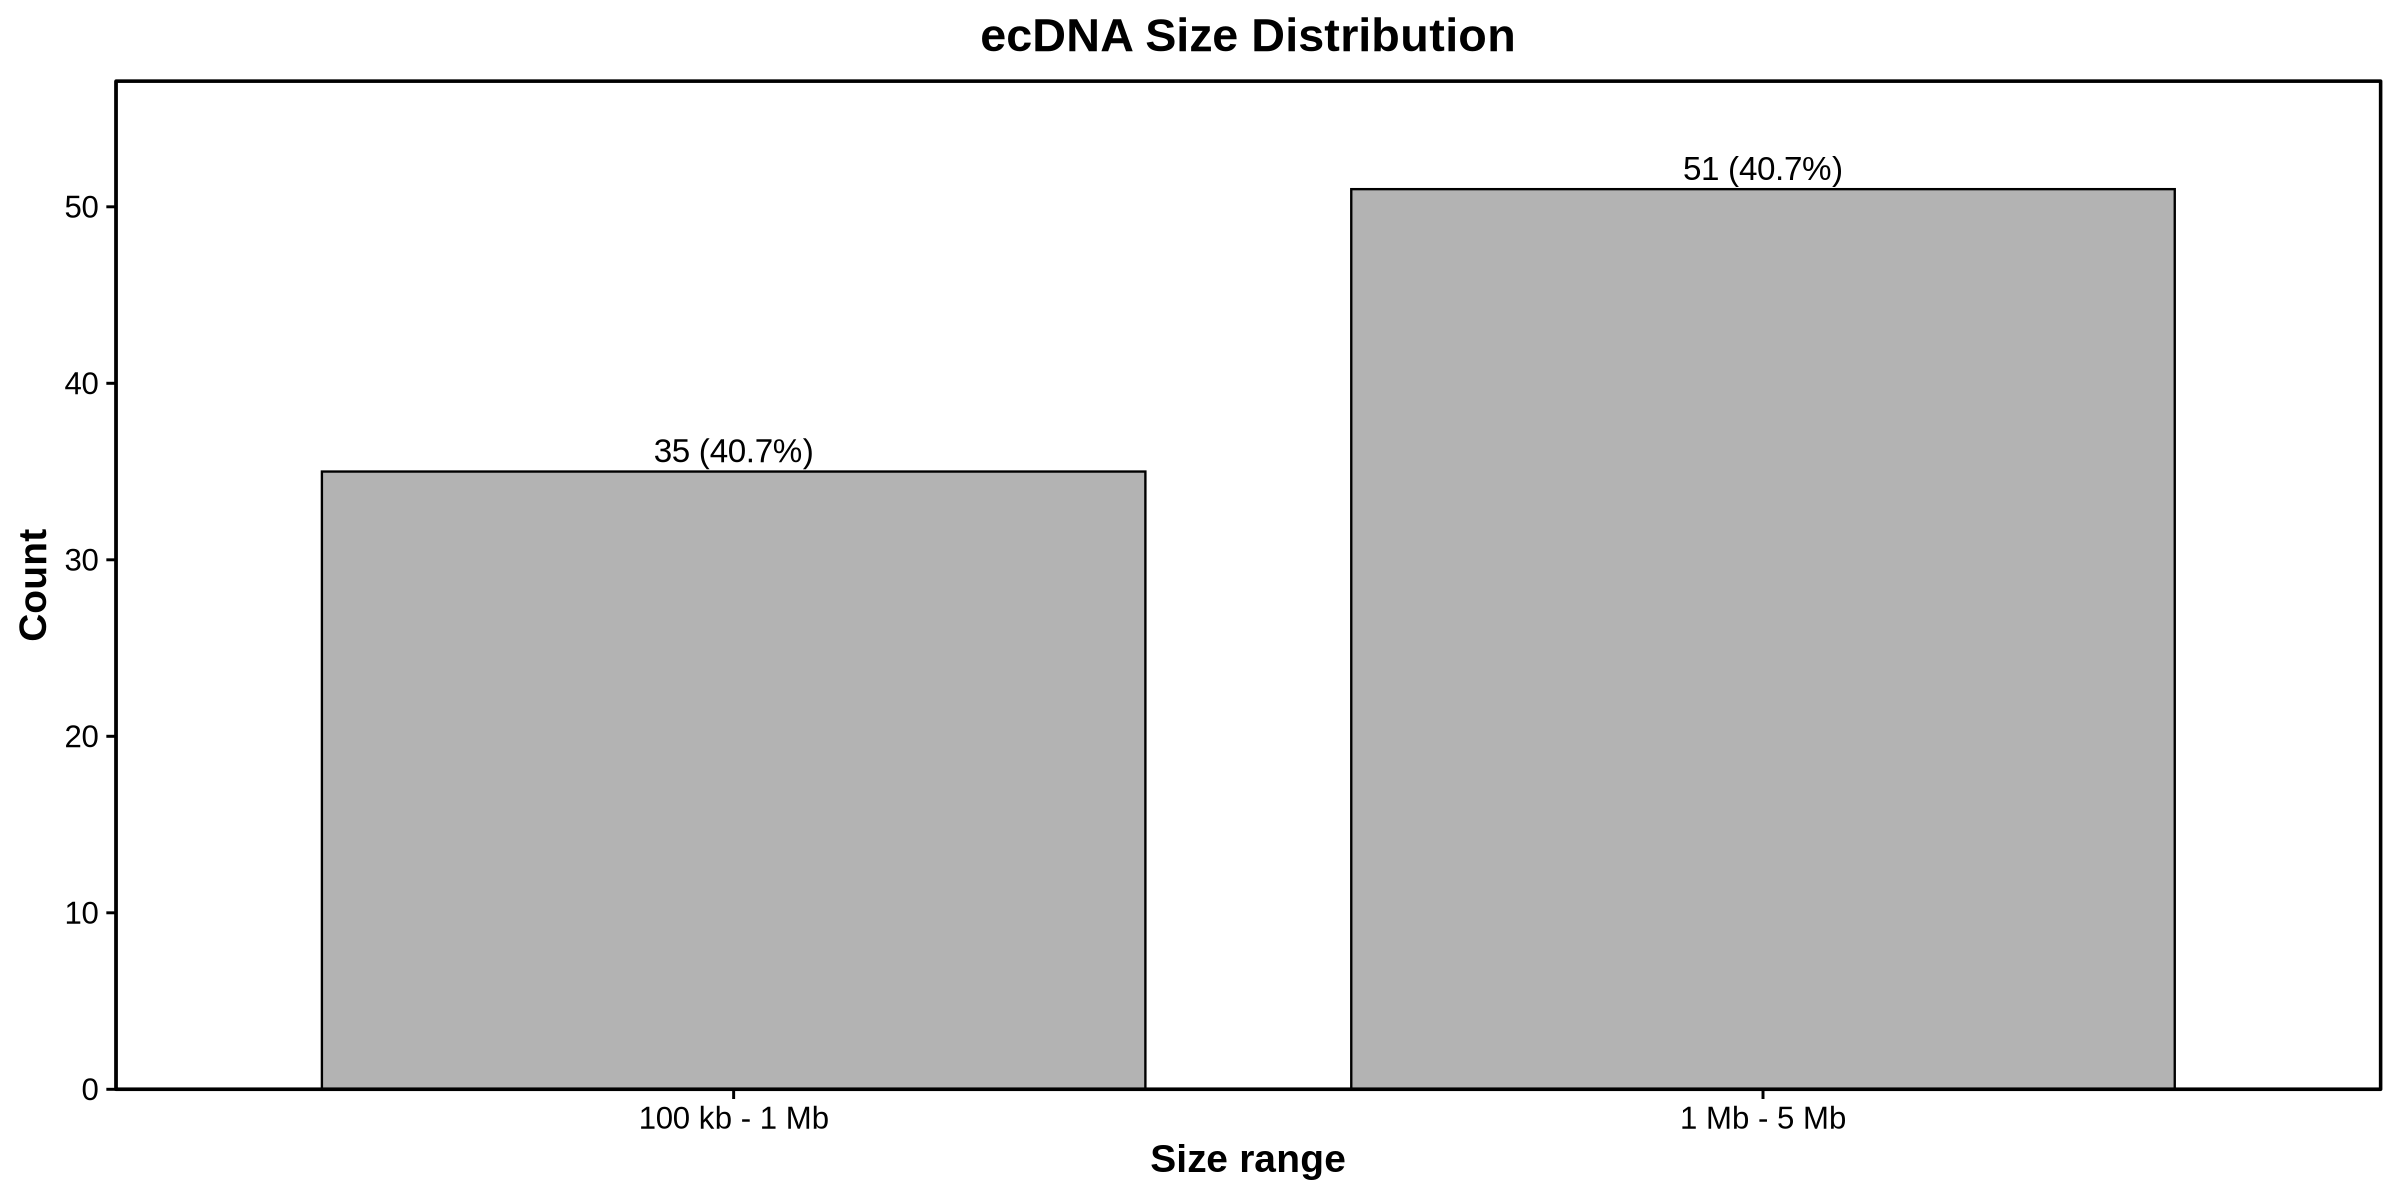

In [153]:
# High-gain size distribution
# ==================================================
ecdna_binned <- cnv_ecdna %>%
  filter(ecDNA_flag == 1, Length >= 1000, Length <= 5e6) %>%
  mutate(
    Length_kb = Length / 1000,
    size_range = case_when(
      Length_kb >= 100 & Length_kb < 1000 ~ "100 kb - 1 Mb",
      Length_kb >= 1000 & Length_kb <= 5000 ~ "1 Mb - 5 Mb",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(size_range)) %>%
  mutate(size_range = factor(size_range, levels = c("100 kb - 1 Mb", "1 Mb - 5 Mb")))

size_counts <- ecdna_binned %>%
  count(size_range, name = "count") %>%
  complete(size_range = factor(c("100 kb - 1 Mb", "1 Mb - 5 Mb"),
                               levels = c("100 kb - 1 Mb", "1 Mb - 5 Mb")),
           fill = list(count = 0)) %>%
  mutate(pct = ifelse(sum(count) > 0, count / sum(count), 0))

p_size_bins <- ggplot(size_counts, aes(x = size_range, y = count)) +
  geom_col(width = 0.8, fill = "grey70", color = "black", linewidth = 0.4) +
  geom_text(aes(label = paste0(count, " (", percent(pct, accuracy = 0.1), ")")), vjust = -0.4, size = 4.2) +
  labs(title = "ecDNA Size Distribution", x = "Size range", y = "Count") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12)), breaks = pretty_breaks()) +
  theme_pub(14) +
  theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6)) +
  coord_cartesian(clip = "off")
print(p_size_bins)
#save_pdf(p_size_bins, file.path(fig6_dir, "size_ecDNA_three_bins.pdf"), 6, 4)

In [154]:
colnames(cnv_ecdna)


[1] "ID"          "chrom"       "loc.start"   "loc.end"     "num.mark"   
 [6] "seg.mean"    "Length"      "CNV_status"  "med_seg"     "mad_seg"    
[11] "ecDNA_flag"  "Absolute_CN"

In [155]:
cnv_arms <- cnv_ecdna %>%
  mutate(chrom_chr = paste0("chr", chrom)) %>%
  rowwise() %>%
  mutate(
    Arm = chr_arm_size$Arm[
      chr_arm_size$Chromosome == chrom_chr &
        loc.end >= chr_arm_size$Start &
        loc.start <= chr_arm_size$End
    ][1]
  ) %>%
  ungroup() %>%
  mutate(
    chr_arm = paste0(chrom_chr, Arm),
    Sample_prefix = as.character(ID)
  ) %>%
  select(-chrom_chr, -Arm)
#write.table(cnv_arms, file = "HGs_with_chr-arms.txt", sep = "\t", quote = FALSE, row.names = FALSE)

merged_data <- telomeres_MAD %>%
  inner_join(cnv_arms, by = c("Sample_prefix", "chr_arm"))
#write.table(merged_data, file = "TEL_merged_HARs_with_chr-arms.txt", sep = "\t", quote = FALSE, row.names = FALSE)
head(merged_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,direction.x,chr_arm,median_TL,mad_TL,⋯,loc.start,loc.end,num.mark,seg.mean,Length,CNV_status,med_seg,mad_seg,ecDNA_flag,Absolute_CN
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,2436A,chr1p,5221.000,1,p,5.221000,Negative,chr1p,5303.000,1180.083,⋯,200151,28021140,130,0.0534,27820989,Neutral,0.0116,0.05922987,0,2.1
2,2436A,chr1q,5051.167,1,q,5.051167,Negative,chr1q,5303.000,1180.083,⋯,142707663,142907814,2,1.3533,200151,Gain,0.0116,0.05922987,1,5.1
3,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,200151,3002265,12,-0.4724,2802114,Loss,-0.1005,0.70497630,0,1.4
4,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,3202416,46034730,207,-0.3523,42832314,Loss,-0.1005,0.70497630,0,1.6
5,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,46234881,54641223,43,-0.2802,8406342,Loss,-0.1005,0.70497630,0,1.6
6,3188,chr1p,1642.500,1,p,1.642500,Negative,chr1p,2824.125,399.500,⋯,54841374,68051340,67,-0.2241,13209966,Loss,-0.1005,0.70497630,0,1.7


In [156]:
# High-gain arm summary
# ==================================================
ecdna_arm_summary <- merged_data %>%
  group_by(Sample_prefix, chr_arm) %>%
  summarise(
    HG_Present = if_else(any(ecDNA_flag == 1), "Yes", "No"),
    HG_Segments = sum(ecDNA_flag == 1, na.rm = TRUE),
    HG_Size_Mb = sum(Length[ecDNA_flag == 1], na.rm = TRUE) / 1e6,
    Avg_HG_Amplification = mean(seg.mean[ecDNA_flag == 1], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(HG_Present == "Yes") %>%
  arrange(desc(HG_Size_Mb))

cat("Total HG arms:", nrow(ecdna_arm_summary), "\n")
cat("Unique chromosomes:",
    ecdna_arm_summary %>% mutate(chrom_num = str_extract(chr_arm, "chr[0-9XY]+")) %>% pull(chrom_num) %>% n_distinct(),
    "\n")
cat("Total samples affected:", n_distinct(ecdna_arm_summary$Sample_prefix), "\n")

print(
  ecdna_arm_summary %>%
    count(chr_arm, name = "Frequency") %>%
    arrange(desc(Frequency)) %>%
    slice_head(n = 3)
)

Total HG arms: 61 
Unique chromosomes: 16 
Total samples affected: 13 
# A tibble: 3 × 2
  chr_arm Frequency
  <chr>       <int>
1 chr14q         11
2 chr15q         10
3 chr10q          5


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `x_log2 = ifelse(seg.mean > 0, log2(seg.mean), NA_real_)`.
Caused by warning in `ifelse()`:
! NaNs produced”
`geom_smooth()` using formula = 'y ~ x'


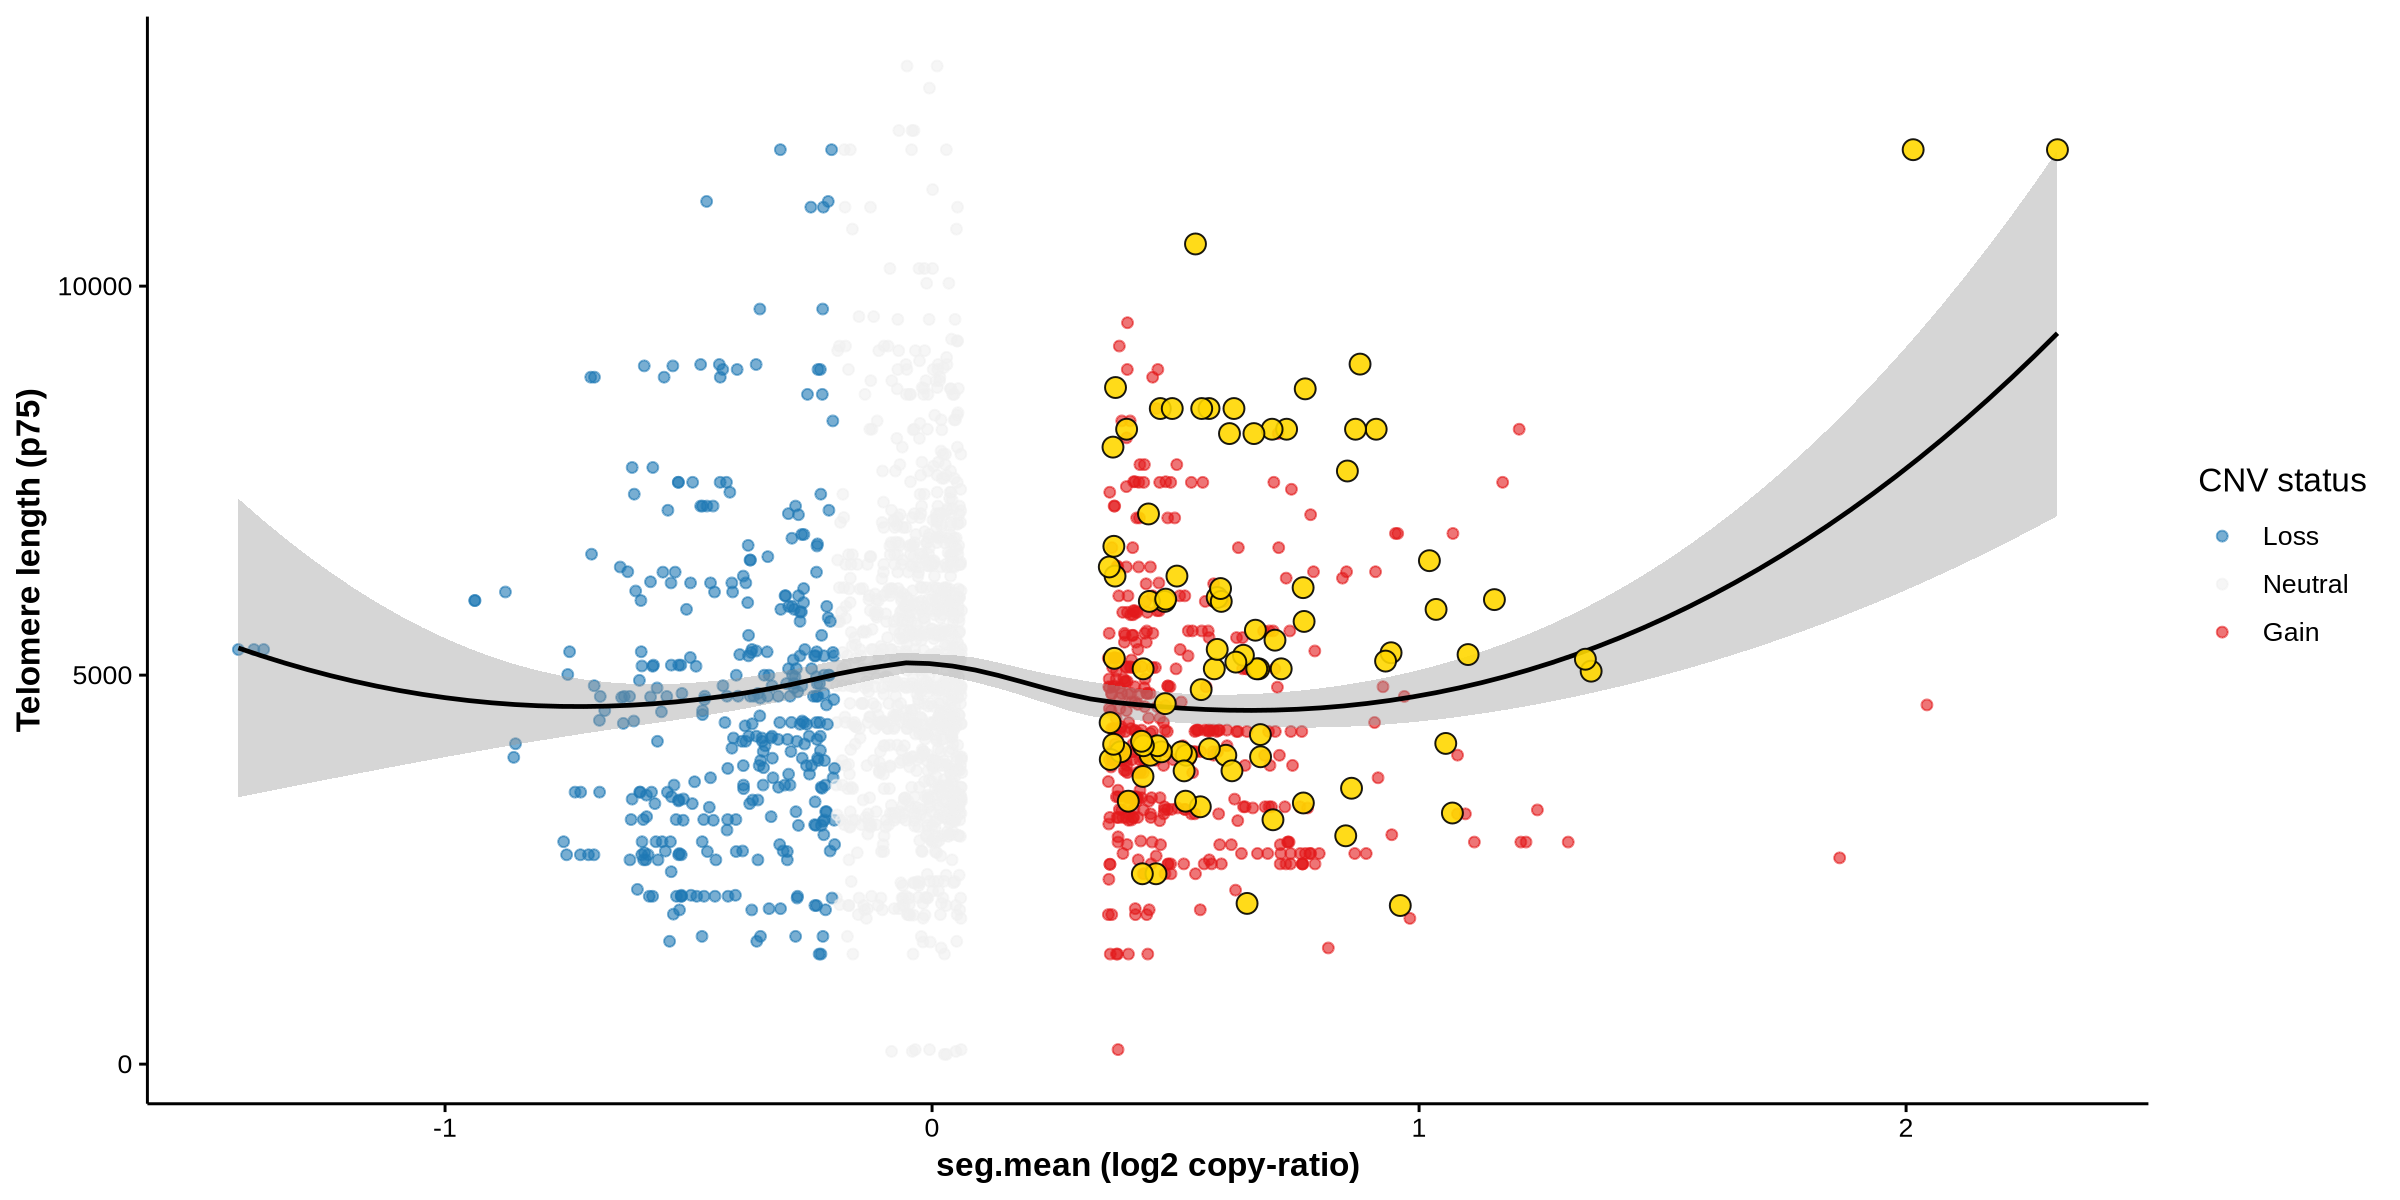

In [157]:
# Telomere vs amplification scatter
# ==================================================
violin_df <- merged_data

plot_df <- violin_df %>%
  mutate(
    seg.mean = as.numeric(seg.mean),
    TL = as.numeric(final_average_TL_p75),
    CNV_status = factor(as.character(CNV_status), levels = c("Loss", "Neutral", "Gain")),
    ecDNA_flag = ifelse(as.character(ecDNA_flag) %in% c("1", "ecDNA", "TRUE", "true"), "ecDNA", "No ecDNA")
  )

log2_ok <- all(plot_df$seg.mean > 0, na.rm = TRUE)
plot_df <- plot_df %>%
  mutate(
    x_log2 = ifelse(seg.mean > 0, log2(seg.mean), NA_real_),
    x = if (log2_ok) x_log2 else seg.mean
  ) %>%
  filter(is.finite(x), is.finite(TL))

x_lab <- if (log2_ok) "log2(seg.mean)" else "seg.mean (log2 copy-ratio)"

p_scatter <- ggplot() +
  geom_point(
    data = filter(plot_df, ecDNA_flag != "ecDNA"),
    aes(x = x, y = TL, color = CNV_status),
    alpha = 0.6, size = 1.5
  ) +
  geom_smooth(data = plot_df, aes(x = x, y = TL), method = "loess", se = TRUE, color = "black", linewidth = 0.8) +
  geom_point(
    data = filter(plot_df, ecDNA_flag == "ecDNA"),
    aes(x = x, y = TL),
    shape = 21, fill = "gold", color = "black", size = 3.2, stroke = 0.5, alpha = 0.9
  ) +
  scale_color_manual(values = cnv_colors, name = "CNV status") +
  labs(x = x_lab, y = "Telomere length (p75)") +
  theme_pub(12) +
  theme(legend.position = "right")
print(p_scatter)
#save_pdf(p_scatter, file.path(fig6_dir, "volcanoplot_ecDNa.pdf"), 8, 6)

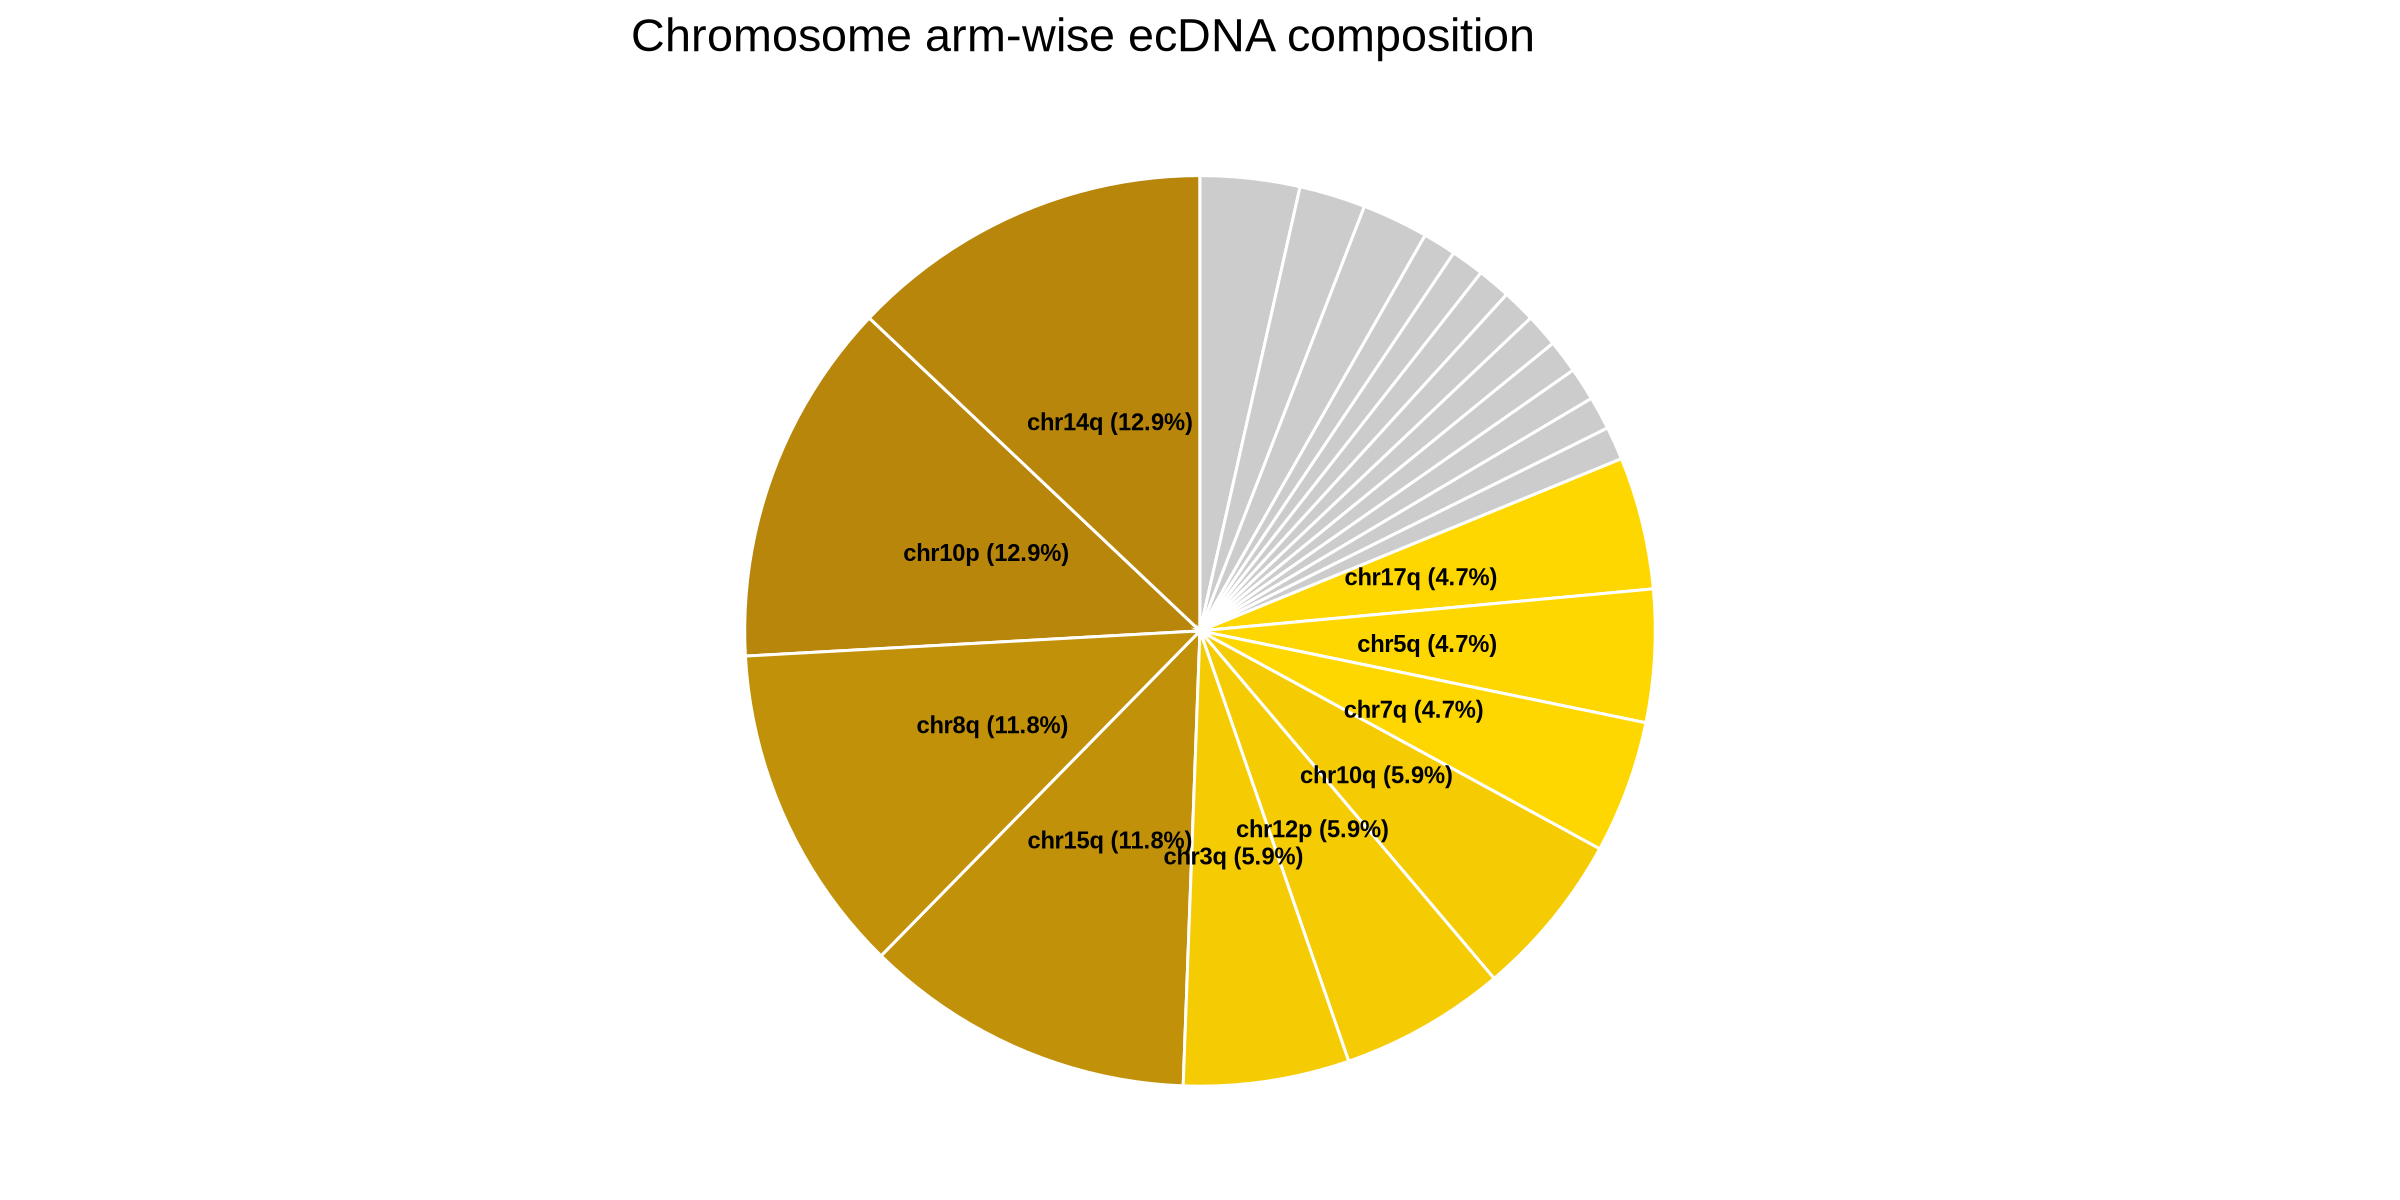

In [158]:
ecDna_DF <- merged_data %>%
  mutate(
    ecDNA_flag = ifelse(as.character(ecDNA_flag) %in% c("1", "ecDNA", "TRUE", "true"),
                        "ecDNA", "No ecDNA")
  ) %>%
  filter(ecDNA_flag == "ecDNA") %>%
  select(Sample_prefix, chr_arm, loc.start, loc.end, final_average_TL_p75)

tab_all <- ecDna_DF %>%
  filter(!is.na(chr_arm), chr_arm != "") %>%
  count(chr_arm, name = "n") %>%
  arrange(desc(n)) %>%
  mutate(
    pct = n / sum(n),
    rank = row_number(),
    lbl = ifelse(rank <= 10, paste0(chr_arm, " (", percent(pct, accuracy = 0.1), ")"), "")
  )

top_n <- min(10, nrow(tab_all))

gold_vals <- if (top_n > 0) {
  scales::col_numeric(
    palette = c("#FFD700", "#B8860B"),
    domain = range(tab_all$pct[1:top_n], na.rm = TRUE)
  )(tab_all$pct[1:top_n])
} else {
  character(0)
}

tab_all$fill_col <- "grey80"
if (top_n > 0) {
  tab_all$fill_col[1:top_n] <- gold_vals
}

p_arm_comp <- ggplot(tab_all, aes(x = "", y = pct, fill = fill_col)) +
  geom_col(color = "white", linewidth = 0.5, width = 1) +
  coord_polar(theta = "y") +
  geom_text(
    aes(label = lbl),
    position = position_stack(vjust = 0.5),
    size = 3,
    color = "black",
    fontface = "bold"
  ) +
  scale_fill_identity() +
  theme_void(base_size = 14) +
  theme(
    #panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8)
  ) +
  labs(title = "Chromosome arm-wise ecDNA composition")

print(p_arm_comp)

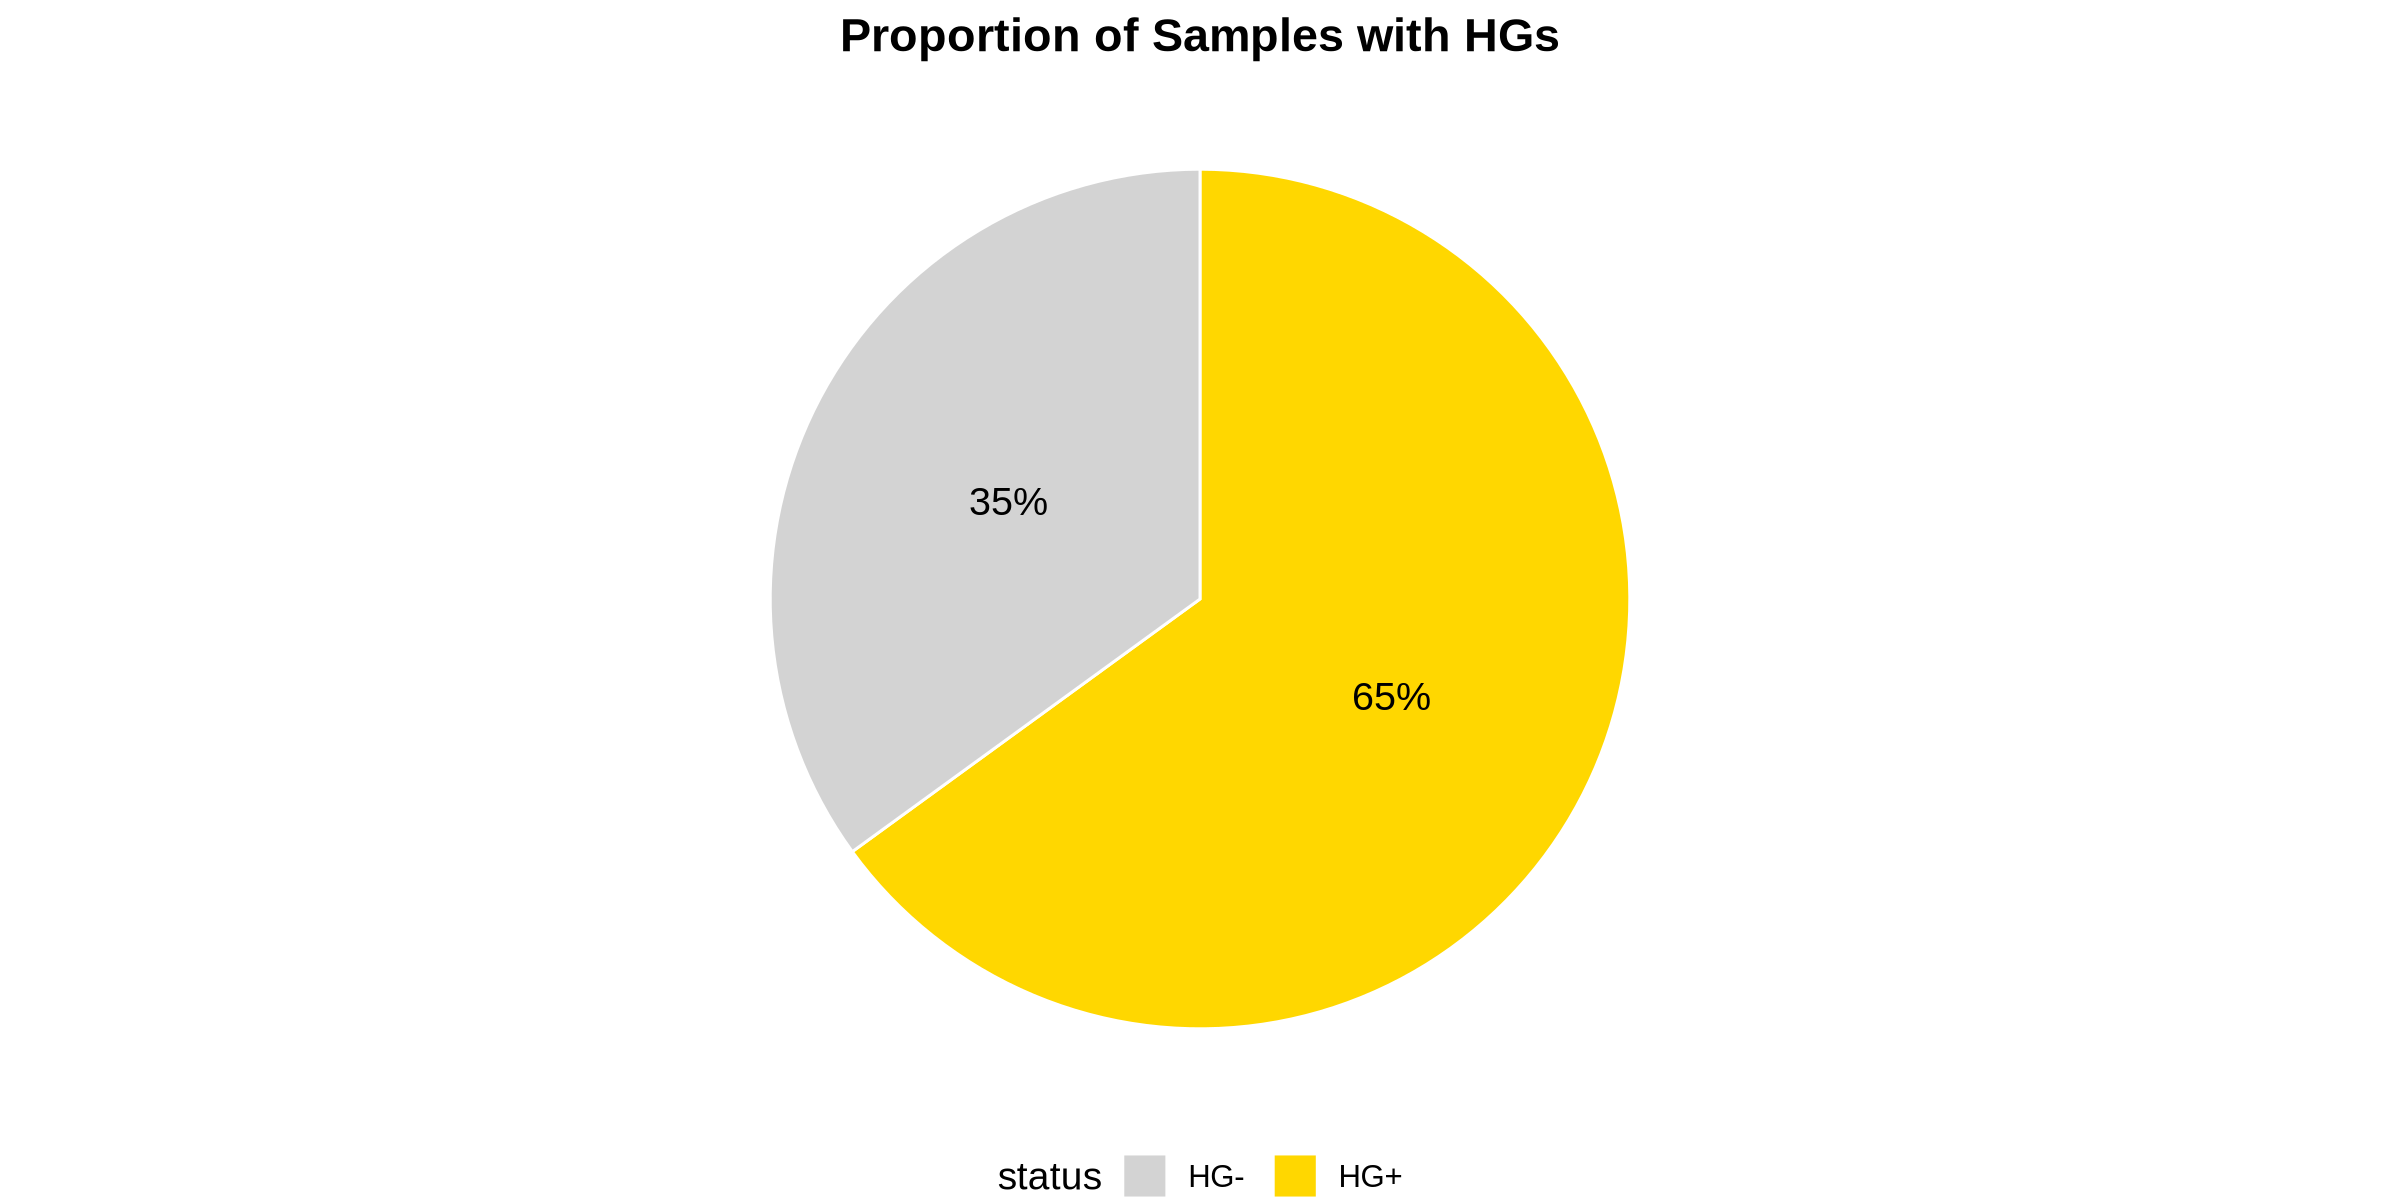

In [159]:
# Proportion of samples with ecDNA
# ==================================================
ecdna_cohort <- cnv_ecdna %>%
  group_by(ID) %>%
  summarise(has_ecDNA = any(ecDNA_flag == 1), .groups = "drop") %>%
  mutate(status = ifelse(has_ecDNA, "HG+", "HG-")) %>%
  count(status) %>%
  mutate(percentage = n / sum(n) * 100)

p_cohort_pie <- ggplot(ecdna_cohort, aes(x = "", y = percentage, fill = status)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  geom_text(aes(label = paste0(round(percentage, 1), "%")), position = position_stack(vjust = 0.5), size = 5) +
  scale_fill_manual(values = c("HG+" = "gold", "HG-" = "lightgrey")) +
  theme_void(base_size = 14) +
  labs(title = "Proportion of Samples with HGs") +
  theme(plot.title = element_text(face = "bold", hjust = 0.5), legend.position = "bottom")
print(p_cohort_pie)
#save_pdf(p_cohort_pie, file.path(fig6_dir, "piechart_ecDNa_conposition.pdf"), 6, 6)

In [ ]:
# HAR repeat annotation
# ==================================================
repeats <- read.delim(repeat_file, header = TRUE, comment.char = "#")
repeats_gr <- GRanges(
  seqnames = repeats$ref,
  ranges = IRanges(start = repeats$beg, end = repeats$end),
  class = repeats$class,
  family = repeats$family
)

# Build high-gain region GRanges
har_gr <- cnv_ecdna %>%
  filter(ecDNA_flag == 1) %>%
  transmute(seqnames = paste0("chr", chrom), start = loc.start, end = loc.end)

g_hg <- GRanges(seqnames = har_gr$seqnames, ranges = IRanges(start = har_gr$start, end = har_gr$end))

hits <- findOverlaps(repeats_gr, g_hg)
repeats_hg <- repeats[queryHits(hits), ]

repeat_summary_chr <- repeats_hg %>%
  group_by(ref, class) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(class) %>%
  mutate(total_class = sum(count)) %>%
  ungroup() %>%
  arrange(desc(total_class)) %>%
  filter(class %in% (repeats_hg %>% count(class, sort = TRUE) %>% slice_head(n = 10) %>% pull(class)))

repeat_summary_chr$ref <- factor(repeat_summary_chr$ref, levels = mixedsort(unique(repeat_summary_chr$ref)))

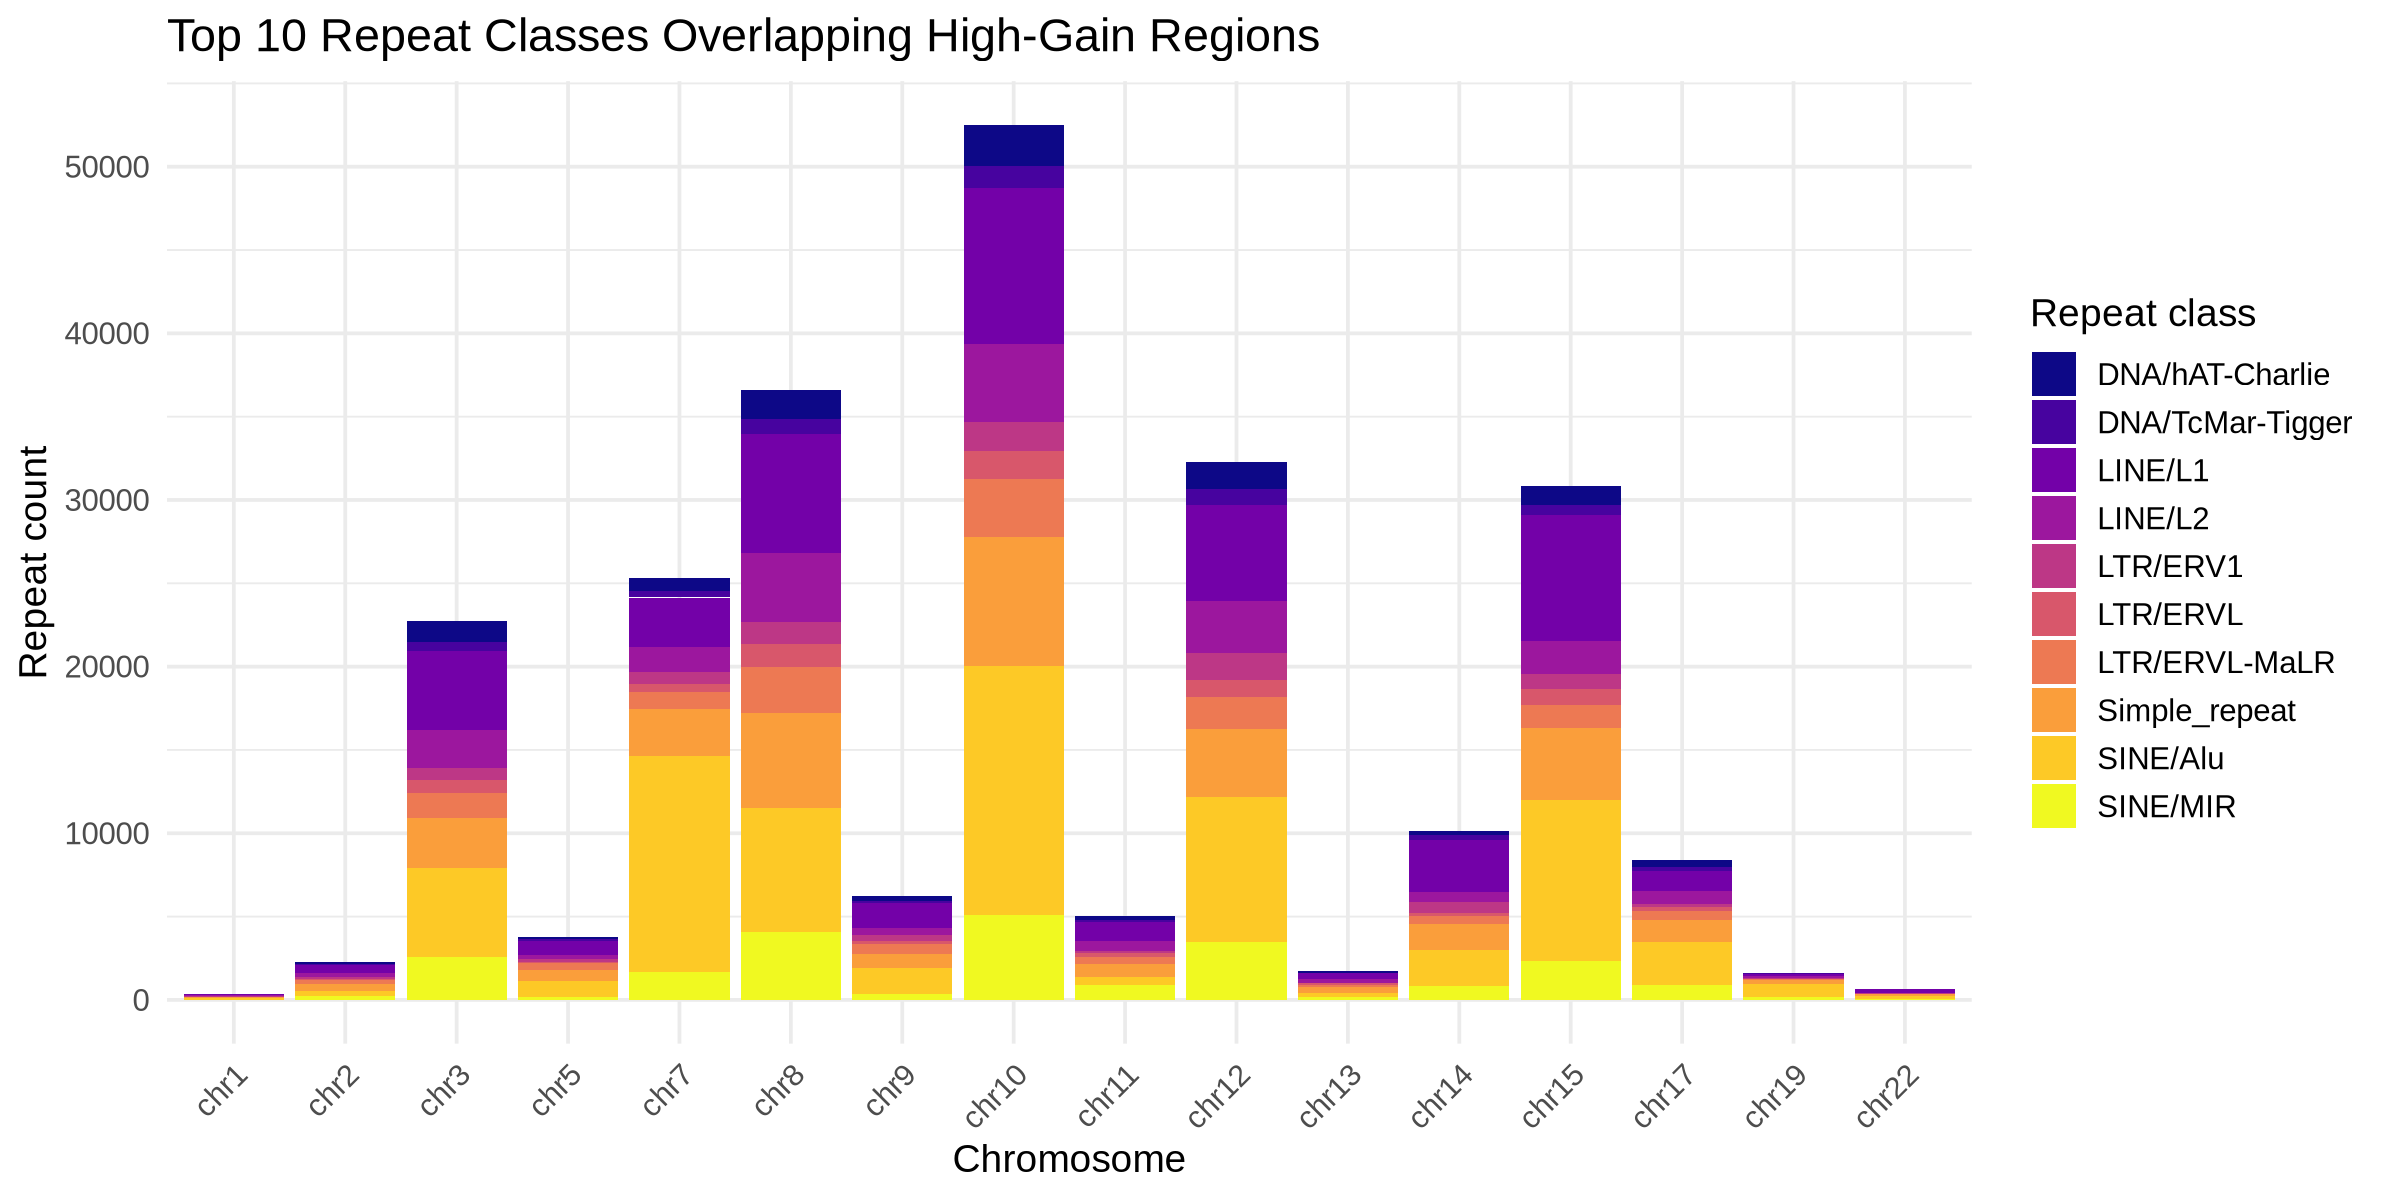

In [137]:
#### REPEATS classes per chromosme
p_repeats <- ggplot(repeat_summary_chr, aes(x = ref, y = count, fill = class)) +
  geom_col() +
  scale_fill_viridis_d(option = "plasma") +
  labs(
    title = "Top 10 Repeat Classes Overlapping High-Gain Regions",
    x = "Chromosome",
    y = "Repeat count",
    fill = "Repeat class"
  ) +
  theme_minimal(base_size = 14) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
print(p_repeats)
#save_pdf(p_repeats, file.path(fig6_dir, "HGs_repeats.pdf"), 6, 4)

In [179]:
gr_exon <- read_bed("/home/mjehangir/softwares/SVAN/chm13/EXONS_chm13.bed")
gr_repeats <- read_bed("/home/mjehangir/softwares/SVAN/chm13/REPEATS_chm13.bed")

ecdna_df <- ecbed %>%
  mutate(
    chrom = as.character(chr),
    start = as.numeric(start),
    end = as.numeric(end)
  ) %>%
  select(chrom, start, end, circ_id, fragment_id, sample)

ecdna_genes <- bed_intersect(ecdna_df, gr_exon)
ecdna_repeats <- bed_intersect(ecdna_df, gr_repeats)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `start = as.numeric(start)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


In [ ]:
# HAR repeat and genes counts per chromosome
# ==================================================
# chromosome order
chr_levels <- c(paste0("chr", 1:22), "chrX", "chrY")

# gene counts per chromosome
gene_counts <- ecdna_genes %>%
  transmute(
    base_chr = as.character(chrom),
    gene = as.character(score.y)
  ) %>%
  filter(!is.na(base_chr), !is.na(gene), gene != "") %>%
  filter(base_chr %in% chr_levels) %>%
  distinct(base_chr, gene) %>%
  count(base_chr, name = "count") %>%
  mutate(feature = "Genes")

# repeat counts per chromosome
repeat_counts <- ecdna_repeats %>%
  transmute(
    base_chr = as.character(chrom)
  ) %>%
  filter(!is.na(base_chr), base_chr %in% chr_levels) %>%
  count(base_chr, name = "count") %>%
  mutate(feature = "Repeats")

# combine
summary_long <- bind_rows(gene_counts, repeat_counts) %>%
  mutate(base_chr = factor(base_chr, levels = chr_levels))

Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_text()`).”


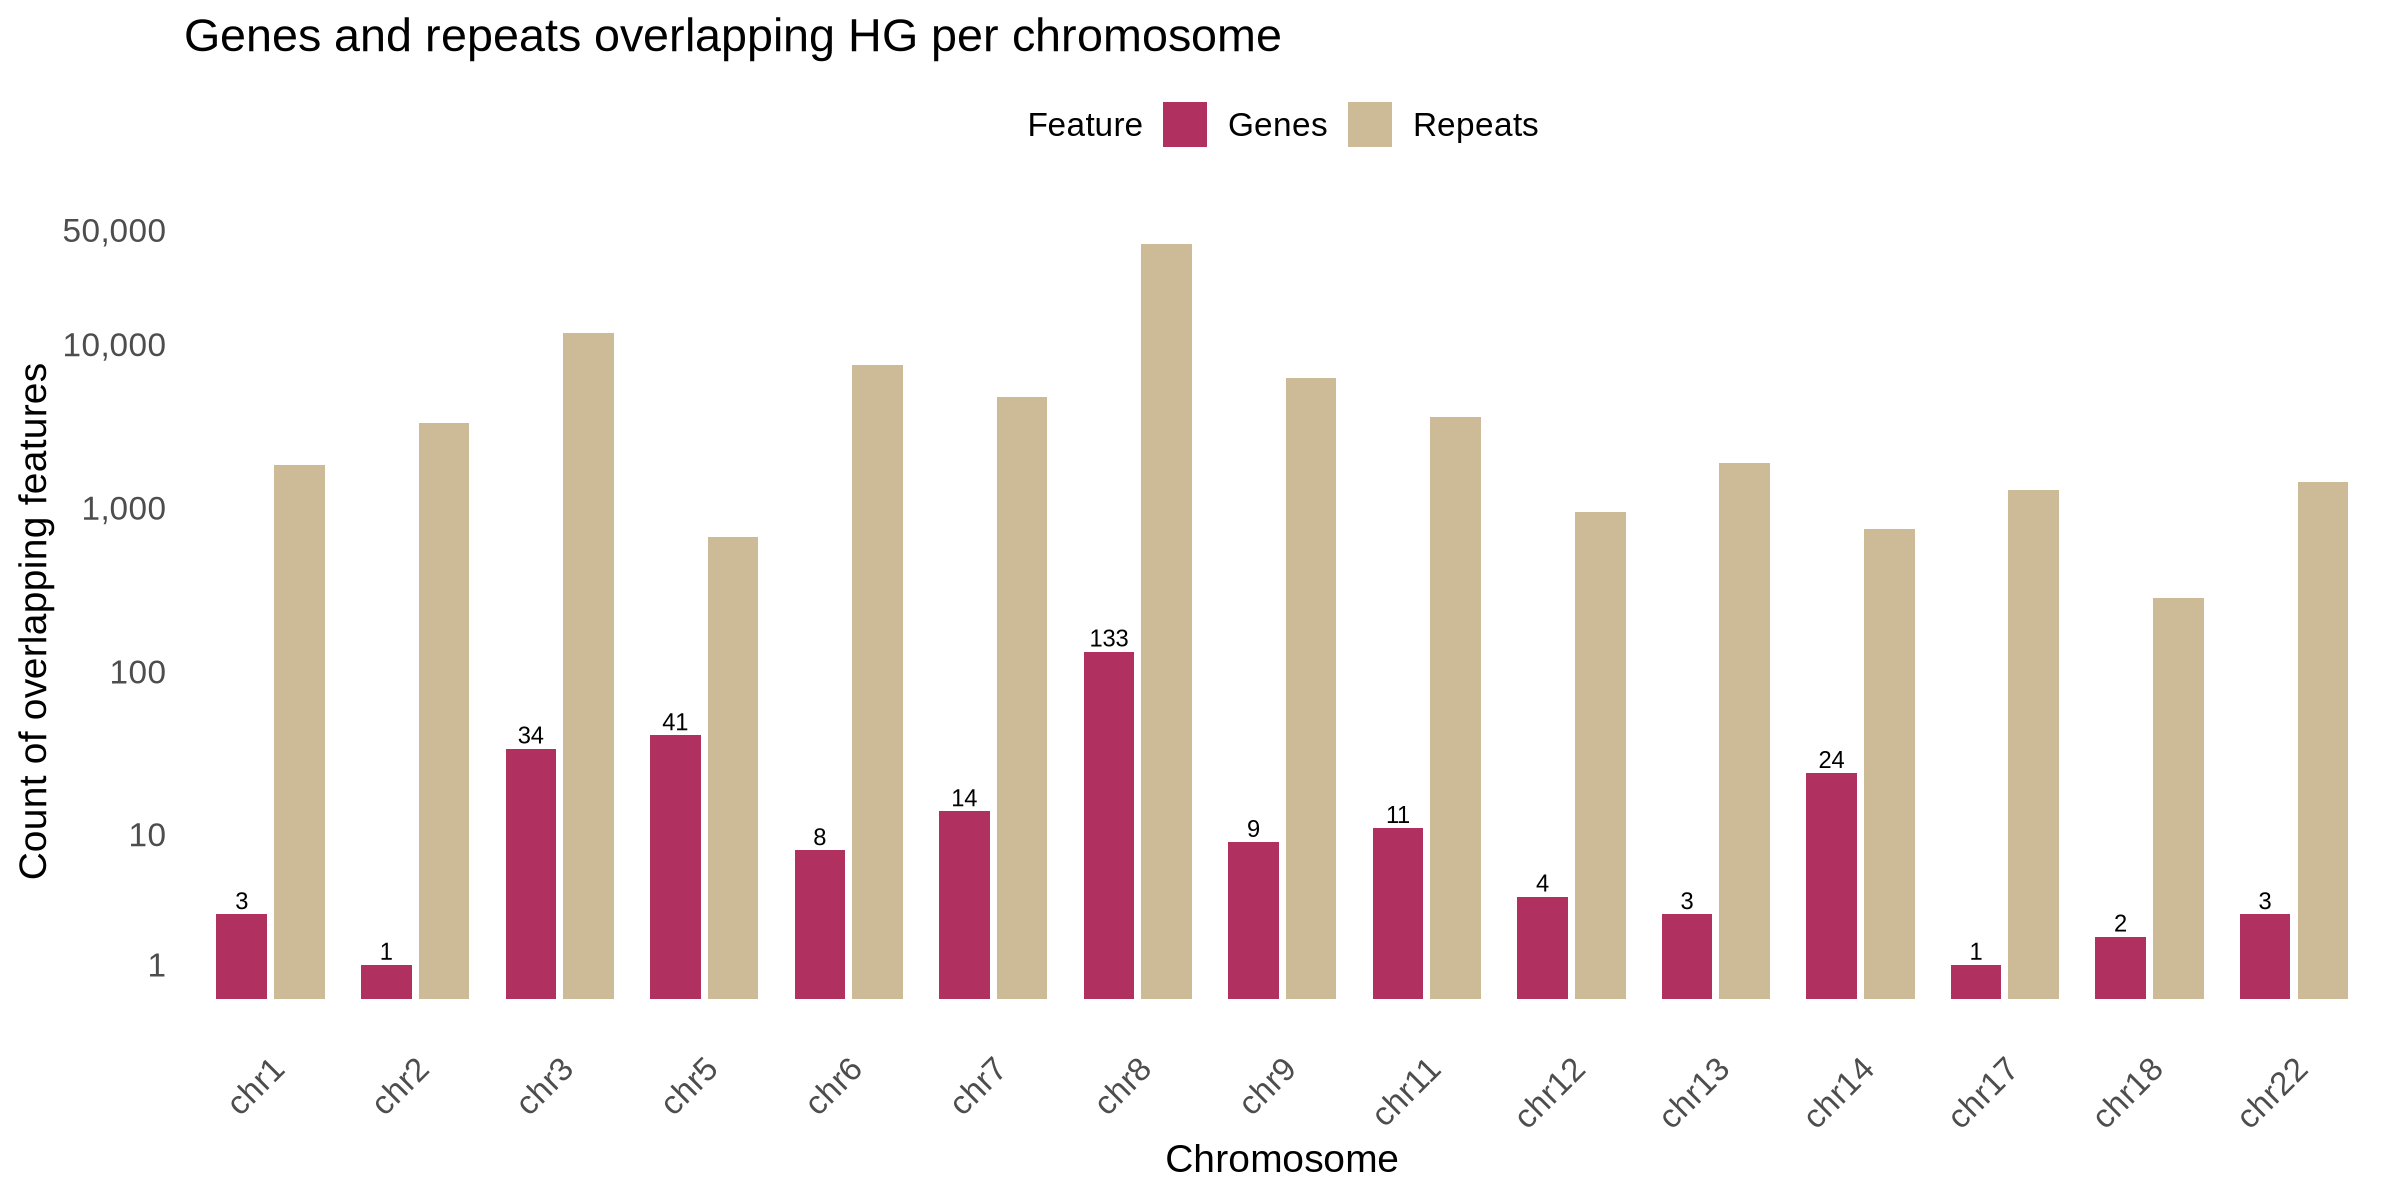

In [162]:
# plot counts
p <- ggplot(summary_long, aes(x = base_chr, y = count, fill = feature)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  scale_y_continuous(
    trans = "pseudo_log",
    breaks = c(1, 10, 100, 1000, 10000, 50000),
    labels = scales::comma
  ) +
  scale_fill_manual(values = c("Genes" = "maroon", "Repeats" = "wheat3")) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.position = "top",
    legend.title = element_text(size = 12),
    legend.text = element_text(size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  labs(
    x = "Chromosome",
    y = "Count of overlapping features",
    fill = "Feature",
    title = "Genes and repeats overlapping HG per chromosome"
  ) +
  geom_text(
    aes(label = ifelse(feature == "Genes", count, NA)),
    position = position_dodge(width = 0.8),
    vjust = -0.3,
    size = 3
  )

print(p)

In [ ]:
# HAR selected genes annotation per chromosome
# ==================================================

target_genes <- c(
  "EZH2", "TEAD4", "KDM5A", "PTK2", "TNK2", "PTP4A3",
  "SGK3", "TRIP13", "ZEB1", "SOX9", "RSPO2", "YWHAZ",
  "VIM", "SERPINE1", "SMURF1", "SHARPIN", "PTHLH", "WNT5B"
)

# Optional: Deduplicate in case of overlaps
target_genes <- unique(target_genes)
chr_levels <- c(paste0("chr", 1:22), "chrX", "chrY")

plot_data <- ecdna_genes %>%
  transmute(
    base_chr = as.character(chrom),
    gene = as.character(score.y)
  ) %>%
  filter(!is.na(base_chr), !is.na(gene), gene != "") %>%
  filter(base_chr %in% chr_levels) %>%
  distinct(base_chr, gene) %>%
  group_by(base_chr) %>%
  summarise(
    total_genes = n_distinct(gene),
    found_targets = paste(intersect(unique(gene), target_genes), collapse = ", "),
    .groups = "drop"
  ) %>%
  mutate(
    base_chr = factor(base_chr, levels = chr_levels)
  )

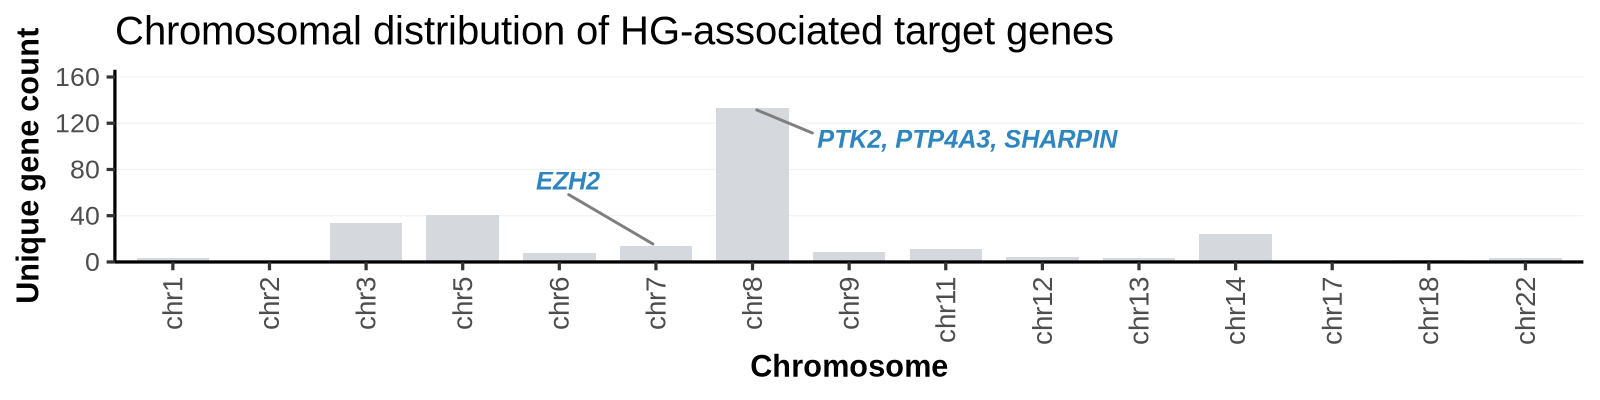

In [182]:
p_targets <- ggplot(plot_data, aes(x = base_chr, y = total_genes)) +
  geom_col(fill = "#D5D8DC", width = 0.75) +
  geom_text_repel(
    data = subset(plot_data, found_targets != ""),
    aes(label = found_targets),
    color = "#2E86C1",
    fontface = "bold.italic",
    size = 3.2,
    box.padding = 1.5,
    point.padding = 0.5,
    min.segment.length = 0,
    segment.color = "grey50",
    segment.linetype = "solid",
    force = 3
  ) +
  theme_classic(base_size = 12) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 10),
    axis.title = element_text(face = "bold", size = 11),
    panel.grid.major.y = element_line(color = "grey95", linewidth = 0.2)
  ) +
  scale_y_continuous(
    expand = expansion(mult = c(0, 0.25)),
    labels = scales::comma
  ) +
  labs(
    x = "Chromosome",
    y = "Unique gene count",
    title = "Chromosomal distribution of HG-associated target genes"
  )

print(p_targets)

In [181]:
head(ecdna_genes)
nrow(ecdna_genes)

chrom,start.x,end.x,circ_id.x,fragment_id.x,sample.x,start.y,end.y,name.y,score.y,strand.y,.overlap
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
chr1,196089010,196200712,1,989.993,2436A,196089873,196090049,EXON,CFH,protein_coding,176
chr1,196089010,196200712,1,989.993,2436A,196092238,196092420,EXON,CFH,protein_coding,182
chr1,196089010,196200712,1,989.993,2436A,196093532,196093925,EXON,CFH,protein_coding,393
chr1,196089010,196200712,1,989.993,2436A,196149801,196149995,EXON,CFHR4,protein_coding,194
chr1,196089010,196200712,1,989.993,2436A,196164219,196164413,EXON,CFHR4,protein_coding,194
chr1,196089010,196200712,1,989.993,2436A,196166906,196167088,EXON,CFHR4,protein_coding,182


[1] 3498